# Louisville Roadway Risk Analysis, 2018 - 2022
### Risk assessment for pedestrians and cyclists in Louisville, KY
All data sourced from [Louisville Metro Open Data](https://data.louisvilleky.gov/)

---


### General Setup and Data Imports

Import libraries needed to assess Louisville data, including geographic data.

In [1]:
import pandas as pd   # for creating dataframes
import geopandas as gpd   # for reading data sets in GeoJSON files
from geopy.distance import geodesic   # for converting shape lengths calculated in degrees to miles
import matplotlib.pyplot as plt   # for plotting visualizations
import matplotlib.patches as mpatches   # for custom visualization labels
from matplotlib import colormaps   # for access to colormaps used in visualizations
from shapely.geometry import Point, LineString, MultiLineString, shape   # for geopandas geometry management
import sqlite3   # for reading to and writing from SQLite database files

Read in various geodata files and shapefiles. Ensure their CRS are aligned, and clip the data to within Jefferson County only.

In [2]:
# geometric shapefile to draw Jefferson County
county_shape = gpd.read_file('data/Ky_County_Polygons/Ky_County_Polygons_WM.shp')
county_shape.to_crs(epsg='4326', inplace=True)      # the GeoJSON files provided by data.louisville.gov use CRS EPSG:4326
jefferson_co = county_shape[county_shape['NAME']=='JEFFERSON']

# major roads data for Louisville metro area includes southern Indiana; clip to Jefferson County
major_roads = gpd.read_file('data/Louisville_Metro_Area_KY_Major_Roads.geojson')
major_roads.dropna(inplace=True)    # one row had mostly NaN values
# clip major roads to Jefferson County only
jeffco_roads = gpd.clip(major_roads, jefferson_co)
jeffco_roads.reset_index(inplace=True, drop=True)
jeffco_roads.name = 'jeffco_roads'

# high injury roadway network data for Louisville metro area includes southern Indiana; clip to Jefferson County
hi_injury = gpd.read_file('data/Louisville_Metro_KY_-_High_Injury_Network.geojson')
hi_injury.name = 'hi_injury'

# bikeways data
bikeways = gpd.read_file('data/Jefferson_County_KY_Bikeways.geojson')
bikeways.name = 'bikeways'

# midblock crossings (crosswalks) data
crosswalks = gpd.read_file('data/Jefferson_County_KY_Midblock_Crossings.geojson')
crosswalks.name = 'crosswalks'

Introductory and exploratory plot demonstrating that all datasets have been reduced to and are contained within Jefferson County, KY

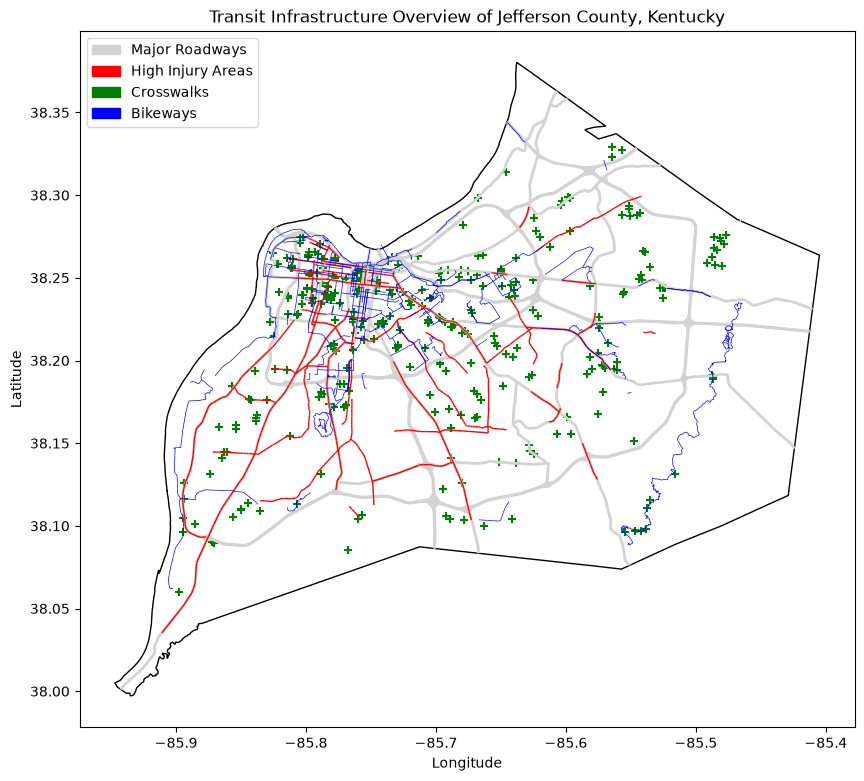

In [3]:
fig, ax = plt.subplots(figsize = (10, 10))

jefferson_co.plot(ax = ax, color='none', edgecolor='black')
jeffco_roads.plot(ax = ax, color='lightgray', linewidth=2) 
hi_injury.plot(ax = ax, color='red', linewidth=1)
crosswalks.plot(ax = ax, color='green', marker="+")
bikeways.plot(ax = ax, color='blue', linewidth=0.5)

grey_lines = mpatches.Patch(color='lightgrey', label='Major Roadways')
red_lines = mpatches.Patch(color='red', label='High Injury Areas')
green_xs = mpatches.Patch(color='green', label='Crosswalks')
blue_lines = mpatches.Patch(color='blue', label='Bikeways')

ax.legend(loc='upper left', handles=[grey_lines, red_lines, green_xs, blue_lines])

plt.title("Transit Infrastructure Overview of Jefferson County, Kentucky")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

### Data Organization and Tidying

Collect dataframes in a list for batch processing of multiple dataframes.

In [4]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks]

Create a function to check dataframes for null values and fill those null value cells with values of the appropriate datatype.

In [5]:
def check_nulls(df):
    df_na = df.columns[df.isna().any()].tolist()
    if not df_na:
        pass   # if there are no missing values, do nothing.
    else:
        for i in df_na:
            if df[i].dtypes == 'str':
                df.fillna({i : 'None'}, inplace=True)   # if the missing value is in a string column, replace NaN with string "None"
            elif df[i].dtypes == 'float64':
                df.fillna({i : 0}, inplace=True)   # if the missing value is in a float column, replace the NaN with 0
            elif df[i].dtypes == 'int32':
                df.fillna({i: 0}, inplace=True)   # if the missing value is in an int column, replace the NaN with 0
            else:
                pass   # we happen to know that there are not other data types in these dataframes that will need to be filled, but further elif statements could be added here for additional datatypes if needed.

Apply null-checking function to all DataFrames being assessed.

In [6]:
for each_set in data_sets:
    check_nulls(each_set)

When any DataFrame is modified, the list of names must be re-initialized. Otherwise, Python will magically pull data from the previous version of the table (since the list was defined before the modification).

In [7]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks]

A key part of this analysis intends to determine how much of Louisville's pedestrian (and cyclist) infrastructure falls within the "[high injury network](https://data.louisvilleky.gov/datasets/LOJIC::louisville-metro-ky-high-injury-network)." Because the GeoJSON files from Louisville Metro Open Data provide geographic shapes like linestrings, we will need to calculate linestring distances in miles. First, however, it must be determined whether amy dataset(s) contains multiple geometry shape types.

In [8]:
def check_shapes(df):
    if df['geometry'].geom_type.nunique() == 1:   # check whether only one geometry type exists in the dataframe, e.g. one consistent type for all values in 'geometry'
        print(f"DataFrame '{df.name}' contains {df.geom_type.nunique()} shape type.")
    else:
        print(f"Dataframe '{df.name}' contains {df.geom_type.nunique()} shape types.")

for each_set in data_sets:
    check_shapes(each_set)

DataFrame 'jeffco_roads' contains 1 shape type.
DataFrame 'hi_injury' contains 1 shape type.
Dataframe 'bikeways' contains 2 shape types.
DataFrame 'crosswalks' contains 1 shape type.


### Modifications and Transformations

*bikeways* contains two pesky rows where the geometry of the shape is MultiLineString.
Rather than defining a sub-function to handle just two anomolous values, GeoPandas can "explode" these. While sounding dramatic, exploding simply breaks the multiple linestrings each into their own new row. 

In [9]:
bikeways_original = bikeways   # back up the original bikeways DataFrame
bikeways = bikeways.explode(ignore_index=True)   # kaboom!
bikeways.name = "bikeways"
check_shapes(bikeways)

DataFrame 'bikeways' contains 1 shape type.


In the *bikeways* DataFrame, values of 1 - 5 are used to identify bikeways by type. The dictionary *bikeway_type* built below maps human-readable descriptions to each value 1 - 5 per the original dataset from https://data.louisvilleky.gov/datasets/LOJIC::jefferson-county-ky-bikeways

In [10]:
# 1 = Separated Bike Lane
# 2 = Bike Lane
# 3 = Neighborway
# 4 = Shared Lane Connection
# 5 = Shared Use Path

bikeway_type = {
    '1': 'Separated Bike Lane',
    '2': 'Bike Lane',
    '3': 'Neighborway',
    '4': 'Shared Lane Connection',
    '5': 'Shared Use Path'
}

Add a column to *bikeways* that indicates the type of bikeway by name rather than by number.

In [11]:
bikeways['TYPE_NAME'] = bikeways['MAP_TYPE'].map(bikeway_type)

The *data_sets* list must be re-defined, otherwise, when passing the list to functions, Python will access the previous values of *bikeways* from when the list was last defined.

In [12]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks]

Geodata files by default provide length as measured in degrees. For a human-readable measure of distance, we must define a function that will calculate the cumulative length of the each segment's "linestring." Linestring is just a list of coordinates stored in an array, readable by *pandas*, *python*, and other software, that can be used to draw the segments accurately on map plots. 

(This step is why the *bikeways* set was 'exploded' above.)

In [13]:
total_line_length = []   # create a list to capture the cumulative segment lengths from the function
def calc_length(line_geometry):
    global total_line_length   # otherwise python won't be able to access 'total_line_length'
    seg_length_mi = 0   # establish baseline segment length (e.g. no length at start)
    coords = list(line_geometry.coords)   # for each time the function is accessed, pull the latitude and longitude coordinates from the linestring values
    for p in range(len(coords) - 1):   
        point1 = (coords[p][1], coords[p][0])   # geopy requires (latitude, longitude)
        point2 = (coords[p+1][1], coords[p+1][0])
        seg_length_mi += geodesic(point1, point2).mi   # add length between points in linestring to total segment length in miles
    total_line_length.append(seg_length_mi)   # finally, add an entry to the running list of distance values

In [14]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks]

Now, apply the *calc_length* function to calculate the distances for each linestring segment, but only in DataFrames whose *geometry* type is *LineString*.

In [15]:
for df in data_sets:  
    if df.at[0,'geometry'].geom_type == 'LineString':   # only addressing datasets whose geometry type is 'LineString'. only one value of the 'geometry' column needs to be evaluated here, since it was previously established that all dataframes have only one 'geom_type'. 
        total_line_length = []   # reset the total line length for each dataset, which is then applied as a new column in the DataFrame
        for ls in df['geometry']:   
            calc_length(ls)   
        if len(total_line_length) != len(df):   # error message and exit loop if function output length does not match DataFrame length
            print(f"The length of the list of distances differs from the length of the DataFrame '{df.name}'.")
            break
        else:   # "else" here means function output length matches DataFrame length
            df['LEN_MILES'] = total_line_length   # so it can be added as a column to the df
    else:
        continue   # if the df in question does not have LineString geometries, move on to the next df 

In [16]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks]

Before performing some calculations and groupings to further analyze roadway risk in Louisville, some secondary DataFrames need to be created using GeoPandas. 

GeoPandas easily handles geographic data types, i.e. linestrings, multilinestrings, and coordinates. SQL, which will be used for aggregation and grouping tasks, does not. Since only *crosswalks* and *hi_injury* include a common distinct key in *RWCOMPKEY*, geographic data operates as the data on which *bikeways* can be meaningly joined with *hi_injury*.

In [17]:
injury_bikeways = gpd.clip(bikeways, hi_injury)   # DataFrame containing only 'bikeways' entries also in the 'hi_injury' set
injury_bikeways.name = 'injury_bikeways'

In [18]:
data_sets = [jeffco_roads, hi_injury, bikeways, crosswalks, injury_bikeways]

### SQLite for Speed

SQL tends to be faster than Python when handling large data sets. SQL is also faster at tasks like aggregation and joins.

SQLite does not recognize *LineString* as a valid datatype. In future enhancements to this project, an adapter callable can be created [as outlined in the Python documentation](https://docs.python.org/3/library/sqlite3.html#sqlite3-types). For our purposes, since distance measures have already been added as a column, the 'geometry' column can simply be omitted (dropped) before passing the DataFrame to SQLite.

In [42]:
connection = sqlite3.connect('data/roadway_risk.db')
cursor = connection.cursor()

for df in data_sets:
    df_nogeo = df.drop('geometry', axis=1)   # drop 'geometry' column
    df_nogeo.to_sql(df.name, connection, if_exists='replace', index=False)   # build SQL tables named to match the DataFrame name

### Assessing Cyclist & Pedestrian Risk

How much of Louisville's bikeways, in mileage, fall in the high-injury network?

In [76]:
pd.read_sql("""

SELECT 
    SUM(b.LEN_MILES) AS bikeways_miles, 
    SUM(i.LEN_MILES) AS risky_miles, 
    SUM(i.LEN_MILES) / SUM(b.LEN_MILES) * 100 AS pct_risky
FROM bikeways b
LEFT JOIN injury_bikeways i ON b.OBJECTID = i.OBJECTID;

""", connection)

,bikeways_miles,risky_miles,pct_risky
0,228.030381,20.451695,8.968846


Roughly 9% of Louisville's total bikeway infrastructure, 20.5 miles, falls in the high injury network of roadways.

Identify the types of bikeway most at-risk for vehicular crashes.

In [ ]:
pd.read_sql("""

SELECT 
    TYPE_NAME AS bikeway_type,
    SUM(LEN_MILES) AS risky_miles
FROM injury_bikeways
GROUP BY TYPE_NAME
ORDER BY SUM(LEN_MILES) DESC;

""", connection)

Which roads have higher than average mileage with potential risk to cyclists? 

In [ ]:
pd.read_sql("""

SELECT 
    ROADNAME AS road_name,
    SUM(LEN_MILES) AS risky_miles
FROM injury_bikeways
GROUP BY ROADNAME
HAVING SUM(LEN_MILES) > (SELECT AVG(LEN_MILES) FROM injury_bikeways)
ORDER BY SUM(LEN_MILES) DESC;

""", connection)

How many of Louisville crosswalks fall in the high-injury network of roadway?

In [78]:
pd.read_sql("""

SELECT 
    COUNT(c.RWCOMPKEY) AS all_crosswalks, 
    COUNT(h.RWCOMPKEY) AS risky_crosswalks, 
    COUNT(h.RWCOMPKEY) / COUNT(c.RWCOMPKEY) * 100 AS pct_risky
FROM crosswalks c
LEFT JOIN hi_injury h ON c.RWCOMPKEY = h.RWCOMPKEY;

""", connection)

,all_crosswalks,risky_crosswalks,pct_risky
0,351,35,0
